In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import shap

from sklearn.model_selection import train_test_split, TimeSeriesSplit, GridSearchCV
from sklearn.linear_model import LogisticRegression
from sklearn.experimental import enable_iterative_imputer
from sklearn.impute import SimpleImputer, KNNImputer, IterativeImputer
from sklearn.metrics import (
    classification_report, accuracy_score, confusion_matrix, 
    f1_score, fbeta_score, precision_score, recall_score,
    matthews_corrcoef, brier_score_loss, RocCurveDisplay, roc_auc_score, make_scorer
)
from sklearn.datasets import make_classification
from sklearn.svm import SVC
from sklearn.preprocessing import OneHotEncoder, MaxAbsScaler, StandardScaler, FunctionTransformer
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.ensemble import (
    RandomForestClassifier, GradientBoostingClassifier, 
    RandomForestRegressor, GradientBoostingRegressor
)  
from sklearn.tree import DecisionTreeRegressor, plot_tree
from sklearn.calibration import CalibrationDisplay
from sklearn.decomposition import PCA
from sklearn.inspection import permutation_importance, partial_dependence
from sklearn.utils.class_weight import compute_class_weight

from imblearn.over_sampling import RandomOverSampler, SMOTE
from xgboost import XGBClassifier

Overall goal: in building a predictive model, we want to successfully predict a hospital closure with enough lead time before it occurs to give the hospital sufficient leeway to make the necessary changes to stay open.

Reading in the full dataset, splitting out columns into categories, and dropping columns that are not needed to create the dataset I'll use for the model:

In [2]:
hospitals_full = pd.read_csv('../data/hospitals_full.csv')

/var/folders/51/zgq0lbb14t13h0_bgn8nntnm0000gn/T/ipykernel_47544/3201850437.py:1: DtypeWarning: Columns (67) have mixed types. Specify dtype option on import or set low_memory=False.
  hospitals_full = pd.read_csv('../data/hospitals_full.csv')


In [3]:
model_data = hospitals_full.drop(columns=['State', 'Zip', 'County','Facility Name','Closed', 'Closure Date','Full Address', 'Prior Name','Tract_Code', 'CBSA_Code', 'CBSA_Title','County_FIPS', 'State_FIPS'])


In [4]:
model_data.shape

(13391, 189)

In [5]:
model_data.head()

,Year,CCN,Medicaid charges,HAC reduction adjustment amount,STATEMENT OF REVENUES AND EXPENSES: Net Income (G3_C1_29),"ADJUSTED SALARIES, Subtotal Salaries",BALANCE SHEET: Prepaid expenses (G_C1THRU4_8),BED DAYS: Total Hospital,Number of Interns & Residents,BALANCE SHEET: Cash on Hand and in Banks (G_C1THRU4_1),...,"Per Capita Phys,Primary Care, Patient Care Non-Fed",Per Capita Short Term Gen Hosp Admissions,Per Capita Short Term General Hosp Beds,Per Capita Total Active D.O.s Non-Federal,Per Capita Total Active M.D.s Non-Federal,Per Capita Total Medicare Inpatient Days Short Term General Hospitals,Per Capita Total Number Hospitals,Percent Persons in Poverty,Population Estimate,"Unemployment Rate, 16+"
0,2010,190044,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,0.000340,0.092921,0.003529,0.0,0.000664,0.241335,0.000065,21.0,61773.0,6.8
1,2011,190044,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,0.000371,0.085783,0.003275,0.0,0.000710,0.230389,0.000065,22.4,61982.0,6.3
2,2012,190044,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,0.000355,0.083247,0.003279,0.0,0.000695,0.244573,0.000065,20.7,61912.0,5.6
3,2013,190044,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,0.000354,0.082776,0.003263,0.0,0.000675,0.262877,0.000064,19.0,62204.0,NaN
4,2014,190044,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,0.000368,0.082386,0.003249,0.0,0.000736,0.269148,0.000048,22.0,62486.0,5.7


#### Exploratory Data Analysis:

How are hospital closures distributed across the years?

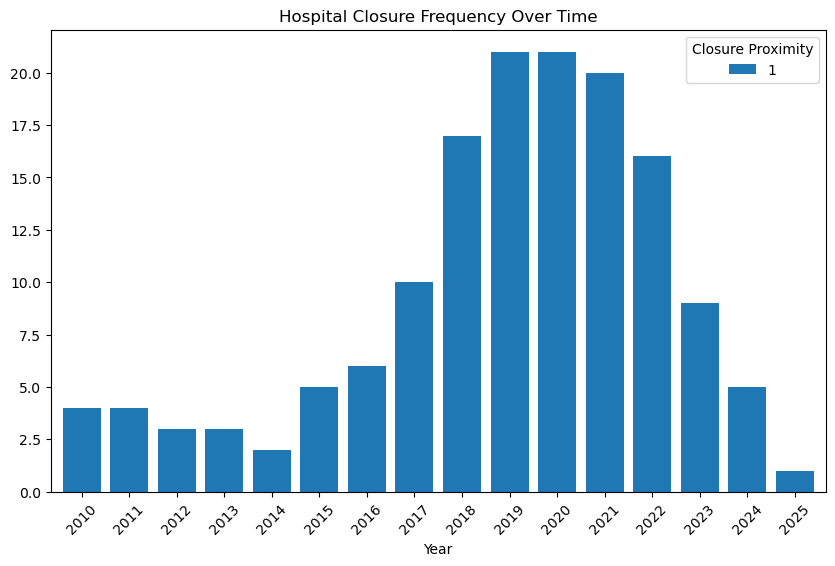

In [6]:
closures = model_data[model_data['Closure Proximity'] == 1]
counts = pd.crosstab(model_data['Year'], closures['Closure Proximity'])
counts.plot(kind='bar', figsize=(10, 6), width=0.8, rot=45)
plt.title('Hospital Closure Frequency Over Time');


There seems to be a slight trend in hospital closure frequency over time, so I'll include year in the model.

Seeing if there is a trend with missing value frequency over time.

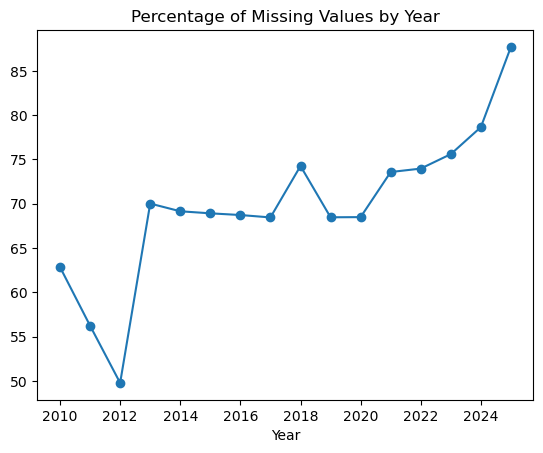

In [7]:
years = model_data['Year']
nan_percentages_all = model_data.drop(columns=['Year']).isna().groupby(years).mean() * 100
nan_percentages = nan_percentages_all.mean(axis=1)
nan_percentages.plot(kind='line',marker='o')
plt.title('Percentage of Missing Values by Year');

Looking at percentage of NaN values per year for a single column per feature type (financial, quality, demographic)

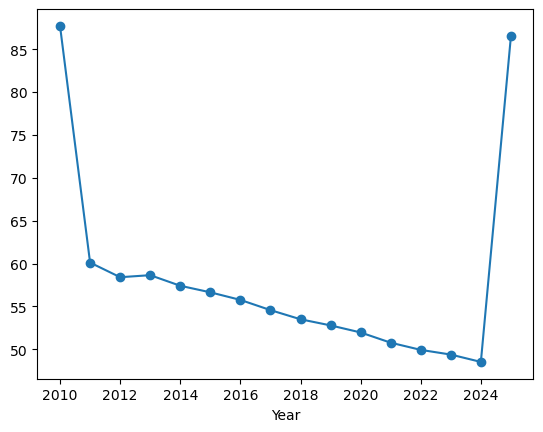

In [8]:
(model_data.groupby('Year')['Financial Indicators: Cash Reserves'].apply(lambda x: x.isna().mean() * 100)).plot(kind='line', marker='o');

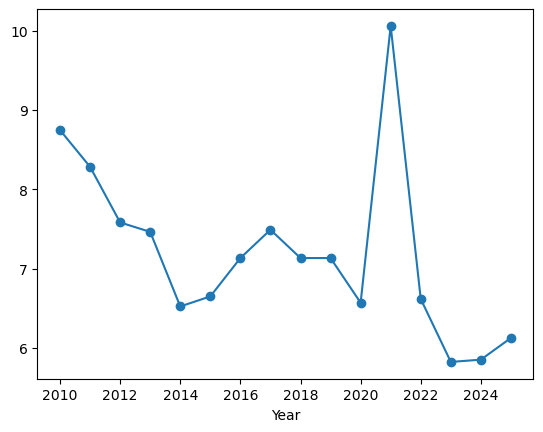

In [9]:
(model_data.groupby('Year')['clean_score'].apply(lambda x: x.isna().mean() * 100)).plot(kind='line', marker='o');

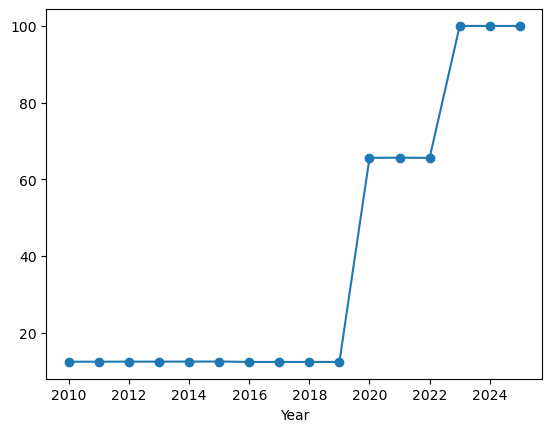

In [10]:
(model_data.groupby('Year')['% <65 without Health Insurance'].apply(lambda x: x.isna().mean() * 100)).plot(kind='line', marker='o');

In [11]:
model_data[model_data['Year']>=2022].isna().mean().sort_values(ascending=False)

scipinf4_denom       1.0
op4_denom            1.0
scipinf3_denom       1.0
scipinf2_denom       1.0
scipinf1_denom       1.0
                    ... 
Hospital Type        0.0
Closure Proximity    0.0
Metro_Status         0.0
RUCA                 0.0
Year                 0.0
Length: 189, dtype: float64

In [12]:
model_data[model_data['Year']<2022].isna().mean().sort_values(ascending=False)

stk_readm_npatients     1.0
pn_readm_npatients      1.0
cabg_readm_npatients    1.0
cabg_mort_npatients     1.0
cabg_readm_rate         1.0
                       ... 
CCN                     0.0
Metro_Status            0.0
Closure Proximity       0.0
Hospital Type           0.0
Year                    0.0
Length: 189, dtype: float64

#### Feature Engineering:

Creating "General Ownership" column to group hospital types into 'govt','non-profit', and 'for-profit':

In [13]:
model_data['Hospital Type'] = model_data['Hospital Type'].replace('Governmental, Federal', 'Government - Federal')

In [14]:
model_data['General Ownership Type'] = model_data['Hospital Type'].replace({'Voluntary non-profit - Other': 'non-profit',
                                            'Voluntary non-profit - Private': 'non-profit',
                                           'Voluntary non-profit - Church': 'non-profit',
                                           'Government - State': 'govt',
                                           'Government - Local': 'govt', 
                                           'Government - Hospital District or Authority': 'govt', 
                                           'Government - Federal': 'govt', 
                                           'Governmental, Other': 'govt',
                                           'Proprietary, Corporation': 'for-profit', 
                                           'Proprietary': 'for-profit', 
                                           'Tribal': 'govt',
                                           'Physician': 'for-profit',
                                           'Non profit - Corporation': 'non-profit'
                                          }, 
                                         )

In [15]:
model_data['General Ownership Type'].isna().sum()

np.int64(0)

In [16]:
model_data['Hospital Type'].nunique()

13

In [17]:
pd.set_option('display.max_rows', None)
model_data.isnull().mean().sort_values(ascending=False)

hf_readm_npatients                                                         1.000000
ami_readm_rate                                                             1.000000
hf_readm_rate                                                              1.000000
pn_mort_rate                                                               1.000000
pn_readm_rate                                                              1.000000
ami_mort_npatients                                                         1.000000
ami_readm_npatients                                                        1.000000
hf_mort_npatients                                                          1.000000
ami_mort_rate                                                              1.000000
pn_mort_npatients                                                          1.000000
pn_readm_npatients                                                         1.000000
all_readm_rate                                                             1

In [18]:
# Drop columns that are more than 80% NaNs
model_data = model_data.loc[:, model_data.isnull().mean() <= 0.80]

In [19]:
model_data.shape

(13391, 94)

This still leaves us with 92 features (94 columns minus CCN and target column)

Breaking down features into large scale types:

In [20]:
id_cols = ['Year','CCN']
target_cols = ['Closure Proximity']
hospital_char_cols = ['General Ownership Type','Emergency Services','Hospital Type']
financial_cols = ['BALANCE SHEET: Total Assets (G_C1THRU4_36)', 'BED DAYS: Total Hospital', 'REIMBURSEMENT SETTLEMENT: Interim payments', 
                  'IPPS Interim payment', 'BALANCE SHEET: Cash on Hand and in Banks (G_C1THRU4_1)', 
                  'BALANCE SHEET: Total Current Liabilities (G_C1THRU4_45)', 'Total cost of charity care', 
                  'HVBP payment adjustment amount', 'Total discharges', 'Total Salaries', 
                  'BALANCE SHEET: Accounts Receivable (G_C1THRU4_4)', 'Net Revenue from Medicaid', 
                  'Total Bad Debt expense', 'Total Charges', 'ADJUSTED SALARIES, Subtotal Salaries', 
                  'NUMBER OF BEDS: Adults & Pediatrics', 'Total Costs', 'BALANCE SHEET: Prepaid expenses (G_C1THRU4_8)', 
                  'BALANCE SHEET: Total Current Assets (G_C1THRU4_11)', 'Cost To Charge Ratio', 'REIMBURSEMENT SETTLEMENT: Subtotal', 
                  'Number of Interns & Residents', 'RECONCILIATION OF CAPITAL COST CENTERS: Depreciation, Total (A7_3_C9_3)', 
                  'Total Inpatient Days', 'STATEMENT OF REVENUES AND EXPENSES: Net Patient Revenue (G3_C1_3)', 
                  'NUMBER OF BEDS: Total Hospital', 'NUMBER OF BEDS: ICU', 'STATEMENT OF REVENUES AND EXPENSES: Net Income (G3_C1_29)', 
                  'BALANCE SHEET: Inventory (G_C1THRU4_7)', 'IPPS Payment amount (unadjusted)', 
                  'TRIAL BALANCE OF EXPENSE ACCOUNTS: Interest Expense (A_C2_113)', 'Cost of Uncompensated Care', 'Medicaid charges', 
                  'Total Liabilities', 'Total Days Title XVIII', 'Financial Indicators: Total Net Assets', 'S-10 DATA: Medicaid Costs', 
                  'Financial Indicators: Cash Reserves', 'Financial Indicators: Net Profit Margin', 'Financial Indicators: Operating Profit', 
                  'Financial Indicators: Operating Profit Margin', 'Financial Indicators: LIQUIDITY current ratio', 
                  'Financial Indicators: LIQUIDITY acid-test ratio', 'Financial Indicators: LIQUIDITY acid-test ratio (variation)', 
                  'Financial Indicators: LIQUIDITY cash ratio', 'Financial Indicators: SOLVENCY Debt-to-Equity Ratio', 
                  'Financial Indicators: SOLVENCY Debt Ratio', 'Financial Indicators: SOLVENCY Equity Ratio', 
                  'Financial Indicators: SOLVENCY Interest Coverage Ratio', 'Financial Indicators: SOLVENCY total assets less total liabilities', 
                  'Financial Indicators: EFFICIENCY asset turnover ratio', 'Financial Indicators: EFFICIENCY Accounts Receivable Turnover Ratio']
hosp_quality_cols = ['nsurveys', 'rrate', 'clean_score', 'commdoc_score', 'commnurse_score', 'explain_score', 'help_score', 
                     'info_score', 'overall_score', 'pain_score', 'quiet_score', 'recommend_score', 'understood_score']
demographic_cols = ['RUCA','Metro_Status','% <65 without Health Insurance', 'Dist Hosp By 00 - 39% Util Rate Short Term General Hospitals', 
                    'Dist Hosp By 40 - 59% Util Rate Short Term General Hospitals', 
                    'Dist Hosp By 60 - 79% Util Rate Short Term General Hospitals', 
                    'Dist Hosp By 80+% Util Rate Short Term General Hospitals', 
                    'Median Household Income', 'Per Capita # Short Term General Hosps', 'Per Capita Hospital Admissions', 
                    'Per Capita Hospital Beds', 'Per Capita Inpatient Days in ST Gen Hosp', 'Per Capita Personal Income', 
                    'Per Capita Phys,Primary Care, Patient Care Non-Fed', 'Per Capita Short Term Gen Hosp Admissions', 
                    'Per Capita Short Term General Hosp Beds', 'Per Capita Total Active D.O.s Non-Federal', 
                    'Per Capita Total Active M.D.s Non-Federal', 'Per Capita Total Medicare Inpatient Days Short Term General Hospitals', 
                    'Per Capita Total Number Hospitals', 'Percent Persons in Poverty', 'Population Estimate', 'Unemployment Rate, 16+']



In [21]:
len(id_cols) + len(target_cols) + len(hospital_char_cols) + len(financial_cols) + len(hosp_quality_cols) + len(demographic_cols) == len(model_data.columns)


True

Are there any hospitals that we don't have any data for?

In [22]:
model_data[model_data[financial_cols + hosp_quality_cols + demographic_cols].isna().all(axis=1)]

,Year,CCN,Medicaid charges,STATEMENT OF REVENUES AND EXPENSES: Net Income (G3_C1_29),"ADJUSTED SALARIES, Subtotal Salaries",BALANCE SHEET: Prepaid expenses (G_C1THRU4_8),BED DAYS: Total Hospital,Number of Interns & Residents,BALANCE SHEET: Cash on Hand and in Banks (G_C1THRU4_1),Cost To Charge Ratio,...,Per Capita Short Term Gen Hosp Admissions,Per Capita Short Term General Hosp Beds,Per Capita Total Active D.O.s Non-Federal,Per Capita Total Active M.D.s Non-Federal,Per Capita Total Medicare Inpatient Days Short Term General Hospitals,Per Capita Total Number Hospitals,Percent Persons in Poverty,Population Estimate,"Unemployment Rate, 16+",General Ownership Type


For every hospital in the dataset, we have at least some financial data, quality data, and/or demographic data.

Ensuring all of the data types are appropriate for the values they represent:

In [23]:
model_data.dtypes

Year                                                                         int64
CCN                                                                          int64
Medicaid charges                                                           float64
STATEMENT OF REVENUES AND EXPENSES: Net Income (G3_C1_29)                  float64
ADJUSTED SALARIES, Subtotal Salaries                                       float64
BALANCE SHEET: Prepaid expenses (G_C1THRU4_8)                              float64
BED DAYS: Total Hospital                                                   float64
Number of Interns & Residents                                              float64
BALANCE SHEET: Cash on Hand and in Banks (G_C1THRU4_1)                     float64
Cost To Charge Ratio                                                       float64
Total discharges                                                           float64
Cost of Uncompensated Care                                                 float64
BALA

In [24]:
model_data['Closure Proximity'] = model_data['Closure Proximity'].astype(int)

In [25]:
model_data['RUCA'] = model_data['RUCA'].astype(object)

#### Data Preprocessing:

In [26]:
numeric_features = [col for col in model_data.select_dtypes('number').columns if col not in ['CCN','Closure Proximity']]

In [27]:
categorical_features = [col for col in model_data.select_dtypes('object').columns]

In [28]:
np.isinf(model_data[numeric_features]).sum().sort_values(ascending=False)

Financial Indicators: LIQUIDITY acid-test ratio                            288
Financial Indicators: LIQUIDITY current ratio                              284
Financial Indicators: LIQUIDITY acid-test ratio (variation)                268
Financial Indicators: LIQUIDITY cash ratio                                 137
Financial Indicators: EFFICIENCY Accounts Receivable Turnover Ratio         61
Financial Indicators: EFFICIENCY asset turnover ratio                       48
Financial Indicators: SOLVENCY Debt Ratio                                   47
Financial Indicators: SOLVENCY Equity Ratio                                 47
Financial Indicators: SOLVENCY Interest Coverage Ratio                      14
Financial Indicators: Operating Profit Margin                                3
Financial Indicators: Net Profit Margin                                      3
Financial Indicators: SOLVENCY Debt-to-Equity Ratio                          1
clean_score                                         

Casting inf values to NaN:

In [29]:
model_data = model_data.replace([np.inf, -np.inf], np.nan)

/var/folders/51/zgq0lbb14t13h0_bgn8nntnm0000gn/T/ipykernel_47544/1911048971.py:1: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  model_data = model_data.replace([np.inf, -np.inf], np.nan)


In [30]:
model_data[categorical_features].isnull().mean().sort_values(ascending=False)

Emergency Services        0.0
RUCA                      0.0
Metro_Status              0.0
Hospital Type             0.0
General Ownership Type    0.0
dtype: float64

None of our categorical variables have missing values, so we don't need to worry about imputing them.

#### Train/test split:

Since there are 16 years in our dataset, we'll reserve 2022-2025 as our real-world test data to achieve a 75%/25% train/test split

In [31]:
cutoff = 2022
train = model_data[model_data['Year'] < 2022]
test = model_data[model_data['Year'] >= 2022]

What proportion of the target classes will that leave us with in the train/test set? Would like to ensure it's not too imbalanced.

In [32]:
train['Closure Proximity'].value_counts(normalize=True).sort_index()

Closure Proximity
0    0.988515
1    0.011485
Name: proportion, dtype: float64

In [33]:
test['Closure Proximity'].value_counts(normalize=True).sort_index()

Closure Proximity
0    0.99058
1    0.00942
Name: proportion, dtype: float64

In [34]:
train['Closure Proximity'].value_counts().sort_index()

Closure Proximity
0    9984
1     116
Name: count, dtype: int64

In [35]:
test['Closure Proximity'].value_counts().sort_index()

Closure Proximity
0    3260
1      31
Name: count, dtype: int64

#### Building a preprocessing pipeline:

In [36]:
# Numeric pipeline
numeric_transformer = Pipeline(steps=[
    ("scaler", StandardScaler()),
    # Applying an iterative imputer to fill missing values
    ("imputer", IterativeImputer(random_state=0, verbose=2, max_iter=50))
])

# Categorical pipeline
categorical_transformer = Pipeline(steps=[
    ("encoder", OneHotEncoder(handle_unknown="ignore", sparse_output=False))
])

# Combine all the transformations into 1 preprocessor
# Using ColumnTransformer to select specific columns and apply transformations
preprocessor = ColumnTransformer(
    transformers=[
        ("num", numeric_transformer, numeric_features),
        ("cat", categorical_transformer, categorical_features)
    ],
    remainder="passthrough",
    verbose_feature_names_out=False
)

pipe = Pipeline(
    steps=[("preprocessor", preprocessor)]
)

#### Hyperparameter Tuning using a validation set:

Here, we'll split our data using k-fold validation and apply the pre-processor pipeline (scaling and filling in missing values). 

Once we have our pre-processed cross-validation datasets, we'll fit a model to each of the training sets and evaluate its effectiveness via the corresponding validation set. 

In [37]:
# Ensure the train set is sorted by year
test = test.sort_values(by='Year')

In [38]:
test.shape

(3291, 94)

In [39]:
k = 5
parts = np.array_split(test, k)

/opt/anaconda3/lib/python3.13/site-packages/numpy/_core/fromnumeric.py:57: FutureWarning: 'DataFrame.swapaxes' is deprecated and will be removed in a future version. Please use 'DataFrame.transpose' instead.
  return bound(*args, **kwds)


In [40]:
# Initialize a dataframe to store model evaluation metrics 
model_evaluation_results = pd.DataFrame(columns=['fold', 'upweight', 'oversample', 'f-beta', 'ROC-AUC', 'precision', 'recall', 'false positives', 'true positives', 'total positives']) 
target = 'Closure Proximity' 

for strategy in ('upweight','oversample'):         
    print(f'BALANCING STRATEGY: {strategy}')    

    # Initialize an empty list to keep track of the training data
    train_parts = []

    for i in range(k-1):
        # Define train and validation sets
        
        # The training set is every part up to the current index combined
        train_parts = [parts[j] for j in range(4) if j <= i]
        train_set = pd.concat(train_parts)
        
        # The validation set is always the part corresponding to the next index
        val_set = parts[i + 1]
    
        # Split into x (features) and y (target) 
        X_train = train_set[[col for col in train_set.columns if col not in ('CCN','Closure Proximity')]] 
        y_train = train_set[target]
                 
        X_val = val_set[[col for col in train_set.columns if col not in ('CCN','Closure Proximity')]] 
        y_val = val_set[target] 
    
        # Preprocessing: Fit and transform the train set
        X_train = pipe.fit_transform(X_train)
        
        # Preprocessing: Transform the validation set 
        X_val = pipe.transform(X_val)
             
        if strategy == 'upweight': 
            upweight = 1 
            oversample = 0 
            neg_count = np.sum(y_train == 0)
            pos_count = np.sum(y_train == 1)
            scale_weight = neg_count / pos_count
            model = XGBClassifier(n_estimators=1000, n_jobs=-1, scale_pos_weight=scale_weight).fit(
                X_train, y_train
            )
        else: 
            upweight = 0 
            oversample = 1 
            # Apply SMOTE oversampling to deal with imbalanced classes 
            smote = SMOTE(random_state=321) 
            X_train_smote, y_train_smote = smote.fit_resample(X_train, y_train) 
                            
            # Initialize and fit a model 
            model = XGBClassifier(n_estimators=1000, n_jobs=-1).fit(X_train_smote, y_train_smote) 
                     
        # Generate predictions on the validation set 
        y_pred = model.predict(X_val) 
        
        # Generate predicted probabiliites
        y_pred_proba = model.predict_proba(X_val)[:,1]

        # Calculate metrics for this specific fold
        prec = precision_score(y_val, y_pred) 
        rec = recall_score(y_val, y_pred) 
        fbeta = fbeta_score(y_val, y_pred, beta=8) 
        roc_auc = roc_auc_score(y_val, y_pred_proba)
        
        cm = confusion_matrix(y_val, y_pred) 
        tp = cm[1,1]
        fp = cm[0,1]
        fn = cm[1,0]
        total_positives = tp + fn
         
        # Append 1 row per fold to the results dataframe
        model_evaluation_results.loc[len(model_evaluation_results)] = [i+1, upweight, oversample, fbeta, roc_auc, prec, rec, fp, tp, total_positives]
        

/opt/anaconda3/lib/python3.13/site-packages/sklearn/utils/extmath.py:1101: RuntimeWarning: invalid value encountered in divide
  updated_mean = (last_sum + new_sum) / updated_sample_count
/opt/anaconda3/lib/python3.13/site-packages/sklearn/utils/extmath.py:1106: RuntimeWarning: invalid value encountered in divide
  T = new_sum / new_sample_count
/opt/anaconda3/lib/python3.13/site-packages/sklearn/utils/extmath.py:1126: RuntimeWarning: invalid value encountered in divide
  new_unnormalized_variance -= correction**2 / new_sample_count
/opt/anaconda3/lib/python3.13/site-packages/sklearn/impute/_base.py:635: UserWarning: Skipping features without any observed values: [28 62]. At least one non-missing value is needed for imputation with strategy='mean'.
  warnings.warn(


BALANCING STRATEGY: upweight
[IterativeImputer] Completing matrix with shape (659, 85)
[IterativeImputer] Ending imputation round 1/50, elapsed time 0.46
[IterativeImputer] Change: 44.147191153535196, scaled tolerance: 0.01796876736125478 
[IterativeImputer] Ending imputation round 2/50, elapsed time 0.81
[IterativeImputer] Change: 89.67657647527108, scaled tolerance: 0.01796876736125478 
[IterativeImputer] Ending imputation round 3/50, elapsed time 1.22
[IterativeImputer] Change: 128.50768686247756, scaled tolerance: 0.01796876736125478 
[IterativeImputer] Ending imputation round 4/50, elapsed time 1.69
[IterativeImputer] Change: 72.21457554353712, scaled tolerance: 0.01796876736125478 
[IterativeImputer] Ending imputation round 5/50, elapsed time 2.22
[IterativeImputer] Change: 33.3957840081843, scaled tolerance: 0.01796876736125478 
[IterativeImputer] Ending imputation round 6/50, elapsed time 2.66
[IterativeImputer] Change: 26.799597848737946, scaled tolerance: 0.01796876736125478 

/opt/anaconda3/lib/python3.13/site-packages/sklearn/impute/_iterative.py:895: ConvergenceWarning: [IterativeImputer] Early stopping criterion not reached.
  warnings.warn(
/opt/anaconda3/lib/python3.13/site-packages/sklearn/impute/_base.py:635: UserWarning: Skipping features without any observed values: [28 62]. At least one non-missing value is needed for imputation with strategy='mean'.
  warnings.warn(


[IterativeImputer] Ending imputation round 23/50, elapsed time 0.21
[IterativeImputer] Ending imputation round 24/50, elapsed time 0.22
[IterativeImputer] Ending imputation round 25/50, elapsed time 0.24
[IterativeImputer] Ending imputation round 26/50, elapsed time 0.24
[IterativeImputer] Ending imputation round 27/50, elapsed time 0.25
[IterativeImputer] Ending imputation round 28/50, elapsed time 0.26
[IterativeImputer] Ending imputation round 29/50, elapsed time 0.27
[IterativeImputer] Ending imputation round 30/50, elapsed time 0.27
[IterativeImputer] Ending imputation round 31/50, elapsed time 0.28
[IterativeImputer] Ending imputation round 32/50, elapsed time 0.28
[IterativeImputer] Ending imputation round 33/50, elapsed time 0.29
[IterativeImputer] Ending imputation round 34/50, elapsed time 0.30
[IterativeImputer] Ending imputation round 35/50, elapsed time 0.30
[IterativeImputer] Ending imputation round 36/50, elapsed time 0.31
[IterativeImputer] Ending imputation round 37/50

/opt/anaconda3/lib/python3.13/site-packages/sklearn/utils/extmath.py:1101: RuntimeWarning: invalid value encountered in divide
  updated_mean = (last_sum + new_sum) / updated_sample_count
/opt/anaconda3/lib/python3.13/site-packages/sklearn/utils/extmath.py:1106: RuntimeWarning: invalid value encountered in divide
  T = new_sum / new_sample_count
/opt/anaconda3/lib/python3.13/site-packages/sklearn/utils/extmath.py:1126: RuntimeWarning: invalid value encountered in divide
  new_unnormalized_variance -= correction**2 / new_sample_count
/opt/anaconda3/lib/python3.13/site-packages/sklearn/impute/_base.py:635: UserWarning: Skipping features without any observed values: [62]. At least one non-missing value is needed for imputation with strategy='mean'.
  warnings.warn(


...

[IterativeImputer] Ending imputation round 19/50, elapsed time 0.19
[IterativeImputer] Ending imputation round 20/50, elapsed time 0.21
[IterativeImputer] Ending imputation round 21/50, elapsed time 0.22
[IterativeImputer] Ending imputation round 22/50, elapsed time 0.22
[IterativeImputer] Ending imputation round 23/50, elapsed time 0.24
[IterativeImputer] Ending imputation round 24/50, elapsed time 0.24
[IterativeImputer] Ending imputation round 25/50, elapsed time 0.25
[IterativeImputer] Ending imputation round 26/50, elapsed time 0.26
[IterativeImputer] Ending imputation round 27/50, elapsed time 0.26
[IterativeImputer] Ending imputation round 28/50, elapsed time 0.27
[IterativeImputer] Ending imputation round 29/50, elapsed time 0.27
[IterativeImputer] Ending imputation round 30/50, elapsed time 0.28
[IterativeImputer] Ending imputation round 31/50, elapsed time 0.29
[IterativeImputer] Ending imputation round 32/50, elapsed time 0.29
[IterativeImputer] Ending imputation round 33/50

/opt/anaconda3/lib/python3.13/site-packages/sklearn/utils/extmath.py:1101: RuntimeWarning: invalid value encountered in divide
  updated_mean = (last_sum + new_sum) / updated_sample_count
/opt/anaconda3/lib/python3.13/site-packages/sklearn/utils/extmath.py:1106: RuntimeWarning: invalid value encountered in divide
  T = new_sum / new_sample_count
/opt/anaconda3/lib/python3.13/site-packages/sklearn/utils/extmath.py:1126: RuntimeWarning: invalid value encountered in divide
  new_unnormalized_variance -= correction**2 / new_sample_count
/opt/anaconda3/lib/python3.13/site-packages/sklearn/impute/_base.py:635: UserWarning: Skipping features without any observed values: [62]. At least one non-missing value is needed for imputation with strategy='mean'.
  warnings.warn(


[IterativeImputer] Completing matrix with shape (2633, 86)
[IterativeImputer] Ending imputation round 1/50, elapsed time 0.62
[IterativeImputer] Change: 77.02143865996749, scaled tolerance: 0.024948008472634012 
[IterativeImputer] Ending imputation round 2/50, elapsed time 1.36
[IterativeImputer] Change: 110.47333457512627, scaled tolerance: 0.024948008472634012 
[IterativeImputer] Ending imputation round 3/50, elapsed time 2.37
[IterativeImputer] Change: 27.682239698880025, scaled tolerance: 0.024948008472634012 
[IterativeImputer] Ending imputation round 4/50, elapsed time 3.07
[IterativeImputer] Change: 12.983799415028342, scaled tolerance: 0.024948008472634012 
[IterativeImputer] Ending imputation round 5/50, elapsed time 3.80
[IterativeImputer] Change: 10.17479783856291, scaled tolerance: 0.024948008472634012 
[IterativeImputer] Ending imputation round 6/50, elapsed time 4.79
[IterativeImputer] Change: 6.580177560807426, scaled tolerance: 0.024948008472634012 
[IterativeImputer] E

/opt/anaconda3/lib/python3.13/site-packages/sklearn/impute/_iterative.py:895: ConvergenceWarning: [IterativeImputer] Early stopping criterion not reached.
  warnings.warn(
/opt/anaconda3/lib/python3.13/site-packages/sklearn/impute/_base.py:635: UserWarning: Skipping features without any observed values: [62]. At least one non-missing value is needed for imputation with strategy='mean'.
  warnings.warn(


[IterativeImputer] Ending imputation round 18/50, elapsed time 0.20
[IterativeImputer] Ending imputation round 19/50, elapsed time 0.22
[IterativeImputer] Ending imputation round 20/50, elapsed time 0.23
[IterativeImputer] Ending imputation round 21/50, elapsed time 0.25
[IterativeImputer] Ending imputation round 22/50, elapsed time 0.25
[IterativeImputer] Ending imputation round 23/50, elapsed time 0.26
[IterativeImputer] Ending imputation round 24/50, elapsed time 0.27
[IterativeImputer] Ending imputation round 25/50, elapsed time 0.27
[IterativeImputer] Ending imputation round 26/50, elapsed time 0.28
[IterativeImputer] Ending imputation round 27/50, elapsed time 0.28
[IterativeImputer] Ending imputation round 28/50, elapsed time 0.29
[IterativeImputer] Ending imputation round 29/50, elapsed time 0.30
[IterativeImputer] Ending imputation round 30/50, elapsed time 0.31
[IterativeImputer] Ending imputation round 31/50, elapsed time 0.31
[IterativeImputer] Ending imputation round 32/50

In [41]:
model_evaluation_results

,fold,upweight,oversample,f-beta,ROC-AUC,precision,recall,false positives,true positives,total positives
0,1.0,1.0,0.0,0.566449,0.931753,0.363636,0.571429,7.0,4.0,7.0
1,2.0,1.0,0.0,0.286344,0.977836,0.333333,0.285714,4.0,2.0,7.0
2,3.0,1.0,0.0,0.335052,0.997201,0.500000,0.333333,1.0,1.0,3.0
3,4.0,1.0,0.0,0.000000,0.976408,0.000000,0.000000,1.0,0.0,1.0
4,1.0,0.0,1.0,0.714286,0.928462,0.714286,0.714286,2.0,5.0,7.0
5,2.0,0.0,1.0,0.285088,0.986395,0.250000,0.285714,6.0,2.0,7.0
6,3.0,0.0,1.0,0.335052,0.997710,0.500000,0.333333,1.0,1.0,3.0
7,4.0,0.0,1.0,0.000000,0.994673,0.000000,0.000000,1.0,0.0,1.0
